# VLST — TabPFN data synthesis comparison (SMOTE family)

Benchmark TabPFN under strong class imbalance with and without synthetic oversampling.

**Why processed features?** SMOTE / ADASYN / Borderline-SMOTE need a numeric metric space with meaningful
distances. The scaled / one-hot matrices from `../modeling/preprocessing/preprocessing.ipynb` match `../modeling/rating/baseline_tssi_leakage.ipynb` and avoid invalid
interpolation on raw integer category codes. TabPFN receives the preprocessed arrays as-is (no extra scaling).

**Methods compared:** baseline (no synthesis), random oversampling (duplicate minority rows), SMOTE, ADASYN, Borderline-SMOTE, SMOTE+Tomek, SMOTE+ENN.

**Leakage control:** synthesis runs on training folds only during OOF threshold tuning; the test set is never
resampled.

## 1. Install dependencies (run once per environment)

In [1]:
import importlib.util
import sys


def _missing(mod):
    return importlib.util.find_spec(mod) is None


to_install = []
if _missing("tabpfn"):
    to_install.append("tabpfn")
if _missing("tabpfn_client"):
    to_install.append("tabpfn-client")
if _missing("imblearn"):
    to_install.append("imbalanced-learn")

if to_install:
    print("Installing:", to_install)
    get_ipython().run_line_magic("pip", "install -q --no-warn-conflicts " + " ".join(to_install))
    print("Done. If imports fail, restart the kernel and re-run.")
else:
    print("tabpfn and imbalanced-learn already available.")

Installing: ['tabpfn', 'tabpfn-client']
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.2/753.2 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.9/370.9 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Done. If imports fail, restart the kernel and re-run.


## 2. Imports and device detection

In [2]:
# Install tabpfn-client (cloud API)
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("tabpfn_client") is None:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "--no-warn-conflicts", "tabpfn-client"]
    )
    print("Installed tabpfn-client. Restart kernel if import fails.")
else:
    print("tabpfn-client already installed.")

tabpfn-client already installed.


In [3]:
import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
    PrecisionRecallDisplay,
)

from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE, RandomOverSampler
from imblearn.combine import SMOTETomek, SMOTEENN

warnings.filterwarnings("ignore")
np.random.seed(42)

is_kaggle_env = os.path.isdir("/kaggle/working")

try:
    import torch

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    DEVICE_NAME = torch.cuda.get_device_name(0) if DEVICE == "cuda" else "CPU"
except Exception:
    DEVICE = "cpu"
    DEVICE_NAME = "CPU"

print(f"Runtime: {'Kaggle' if is_kaggle_env else 'local'} | TabPFN device: {DEVICE} ({DEVICE_NAME})")

Runtime: Kaggle | TabPFN device: cpu (CPU)


## 3. Configuration

In [4]:
DROP_FEATURES = ["Time since stent implantation"]
RANDOM_STATE = 42

# TabPFN inference knobs (mirrors tabpfn.ipynb §3)
N_ESTIMATORS_LOCAL = -1                # local engine only (-1 = TabPFN default ensemble)
TABPFN_CLIENT_N_ESTIMATORS = max(      # cloud API requires n_estimators >= 1
    int(os.environ.get("TABPFN_N_ESTIMATORS", "8")), 1
)
USE_TABPFN_CLIENT = False

# Threshold tuning
THRESHOLD_STRATEGY = "f2"
THRESHOLD_BETA = 1.5
MIN_PRECISION = 0.40
TARGET_RECALL = 0.80
THRESHOLD_CV_SPLITS = 10

# Kaggle paths
KAGGLE_PROCESSED_DIR = "/kaggle/input/datasets/amirmahdidaraei/preprocessed-data"
KAGGLE_RESULT_SUBDIR = "modeling_tabpfn"

if is_kaggle_env:
    USE_TABPFN_CLIENT = DEVICE != "cuda"
    print(
        "Kaggle mode: USE_TABPFN_CLIENT =", USE_TABPFN_CLIENT,
        "(local GPU)" if not USE_TABPFN_CLIENT else "(cloud API)",
    )

N_ESTIMATORS = TABPFN_CLIENT_N_ESTIMATORS if USE_TABPFN_CLIENT else N_ESTIMATORS_LOCAL
print(f"Config ready. n_estimators={N_ESTIMATORS} ({'cloud client' if USE_TABPFN_CLIENT else 'local GPU'})")

Kaggle mode: USE_TABPFN_CLIENT = True (cloud API)
Config ready. n_estimators=8 (cloud client)


## 4. Load processed data

In [5]:
def _find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for d in (here, *here.parents):
        if (d / "data" / "processed" / "X_train.npy").is_file():
            return d
    raise FileNotFoundError(
        "Could not locate data/processed/X_train.npy above the current working directory."
    )


def _resolve_paths():
    if is_kaggle_env:
        processed = Path(os.environ.get("VLST_PROCESSED_DIR", KAGGLE_PROCESSED_DIR))
        result = Path(
            os.environ.get(
                "VLST_RESULT_DIR",
                str(Path("/kaggle/working") / KAGGLE_RESULT_SUBDIR),
            )
        )
        return processed, result, f"Kaggle | processed={processed}"

    repo = _find_repo_root()
    return (
        repo / "data" / "processed",
        repo / "data" / "result" / "modeling_tabpfn",
        f"local | repo={repo}",
    )


PROCESSED_DIR, RESULT_DIR, _path_label = _resolve_paths()
PROCESSED_DIR = Path(PROCESSED_DIR)
RESULT_DIR = Path(RESULT_DIR)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
print(_path_label)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("RESULT_DIR:", RESULT_DIR)


def load_processed():
    Xtr = np.load(PROCESSED_DIR / "X_train.npy")
    Xte = np.load(PROCESSED_DIR / "X_test.npy")
    ytr = np.load(PROCESSED_DIR / "y_train.npy")
    yte = np.load(PROCESSED_DIR / "y_test.npy")
    names = pd.read_csv(PROCESSED_DIR / "feature_names.csv")["feature_name"].tolist()
    fn = np.array(names)
    keep = ~np.isin(fn, DROP_FEATURES)
    return Xtr[:, keep], Xte[:, keep], ytr, yte, fn[keep].tolist()


if not (PROCESSED_DIR / "X_train.npy").is_file():
    raise FileNotFoundError(
        f"{PROCESSED_DIR / 'X_train.npy'} not found. Run ../modeling/preprocessing/preprocessing.ipynb first."
    )

X_train, X_test, y_train, y_test, feature_names = load_processed()
print(f"Train: {X_train.shape} | Test: {X_test.shape} | Features: {len(feature_names)}")
print(
    f"Train target: 0={int((y_train == 0).sum())}, 1={int((y_train == 1).sum())} | "
    f"Test: 0={int((y_test == 0).sum())}, 1={int((y_test == 1).sum())}"
)

_n_minority = int((y_train == 1).sum())
SYNTHESIS_K_NEIGHBORS = min(5, _n_minority - 1) if _n_minority > 1 else 1
print(f"Synthesis k_neighbors = {SYNTHESIS_K_NEIGHBORS}")

Kaggle | processed=/kaggle/input/datasets/amirmahdidaraei/preprocessed-data
PROCESSED_DIR: /kaggle/input/datasets/amirmahdidaraei/preprocessed-data
RESULT_DIR: /kaggle/working/modeling_tabpfn
Train: (3629, 88) | Test: (1556, 88) | Features: 88
Train target: 0=3565, 1=64 | Test: 0=1528, 1=28
Synthesis k_neighbors = 5


## 5. TabPFN helpers and synthesis pipeline

In [6]:
_KAGGLE_SECRET_NAMES = ("tabpfn_token_h", "TABPFN_TOKEN_H", "TABPFN_TOKEN")


def _load_tabpfn_token() -> str:
    """Resolve TabPFN API token from env or Kaggle secrets (no HF_TOKEN required)."""
    for key in ("tabpfn_token_h", "TABPFN_TOKEN_H", "TABPFN_TOKEN"):
        token = os.environ.get(key, "").strip()
        if token:
            print(f"TabPFN token loaded from env var {key!r}.")
            return token

    if is_kaggle_env:
        from kaggle_secrets import UserSecretsClient

        client = UserSecretsClient()
        for label in _KAGGLE_SECRET_NAMES:
            try:
                token = str(client.get_secret(label)).strip()
                if token:
                    print(f"TabPFN token loaded from Kaggle secret {label!r}.")
                    return token
            except Exception:
                continue

    raise RuntimeError(
        "TabPFN API token missing. Set one of: TABPFN_TOKEN, TABPFN_TOKEN_H, tabpfn_token_h "
        "(environment variable) or add a Kaggle secret named tabpfn_token_h. "
        "Get a key at https://ux.priorlabs.ai/account"
    )


tabpfn_token = _load_tabpfn_token()
os.environ["TABPFN_TOKEN"] = tabpfn_token
os.environ["tabpfn_token_h"] = tabpfn_token

if USE_TABPFN_CLIENT:
    import tabpfn_client

    tabpfn_client.set_access_token(tabpfn_token)
else:
    print("Using local TabPFN engine on", DEVICE)


def make_tabpfn(seed=RANDOM_STATE):
    if USE_TABPFN_CLIENT:
        from tabpfn_client import TabPFNClassifier as ClientClf

        return ClientClf(
            n_estimators=N_ESTIMATORS,
            random_state=seed,
        )

    from tabpfn import TabPFNClassifier

    return TabPFNClassifier(
        device=DEVICE,
        n_estimators=N_ESTIMATORS,
        random_state=seed,
    )


def pos_proba(clf, X):
    classes = list(clf.classes_)
    idx = classes.index(1) if 1 in classes else 1
    return np.asarray(clf.predict_proba(X)[:, idx], dtype=float)


def select_threshold(
    y_true,
    scores,
    *,
    strategy="f2",
    beta=2.0,
    min_precision=0.30,
    target_recall=0.80,
    grid_points=199,
):
    grid = np.linspace(0.01, 0.99, grid_points)
    P, R, F1, FB = [], [], [], []
    for t in grid:
        pred = (scores >= t).astype(int)
        P.append(precision_score(y_true, pred, zero_division=0))
        R.append(recall_score(y_true, pred, zero_division=0))
        F1.append(f1_score(y_true, pred, zero_division=0))
        FB.append(fbeta_score(y_true, pred, beta=beta, zero_division=0))
    P, R, F1, FB = map(np.asarray, (P, R, F1, FB))

    if strategy == "f1":
        i = int(np.argmax(F1))
    elif strategy in ("f2", "fbeta"):
        i = int(np.argmax(FB))
    elif strategy == "recall_at_precision":
        ok = np.where(P >= min_precision)[0]
        i = int(ok[np.argmax(R[ok])]) if len(ok) else int(np.argmax(F1))
    elif strategy == "target_recall":
        ok = np.where(R >= target_recall)[0]
        i = int(ok[np.argmax(P[ok])]) if len(ok) else int(np.argmax(R))
    else:
        raise ValueError(f"Unknown THRESHOLD_STRATEGY: {strategy}")

    info = {
        "precision": float(P[i]),
        "recall": float(R[i]),
        "f1": float(F1[i]),
        f"f{beta:g}": float(FB[i]),
    }
    return float(grid[i]), info


_imputer = SimpleImputer(strategy="median")


def apply_synthesis(sampler, X, y):
    """Median-impute then resample. Returns original data if synthesis fails."""
    X_imp = _imputer.fit_transform(X)
    try:
        X_res, y_res = sampler.fit_resample(X_imp, y)
        return np.asarray(X_res, dtype=float), np.asarray(y_res)
    except Exception as exc:
        print(f"  [warn] synthesis failed ({exc}); using original train fold.")
        return X, y


def _k_neighbors(y):
    n_min = int((y == 1).sum())
    return min(SYNTHESIS_K_NEIGHBORS, max(n_min - 1, 1))


def _smote_for(y):
    return SMOTE(k_neighbors=_k_neighbors(y), random_state=RANDOM_STATE)


METHODS = {
    "baseline": None,
    "random_oversample": lambda y: RandomOverSampler(random_state=RANDOM_STATE),
    "smote": lambda y: SMOTE(k_neighbors=_k_neighbors(y), random_state=RANDOM_STATE),
    "adasyn": lambda y: ADASYN(n_neighbors=_k_neighbors(y), random_state=RANDOM_STATE),
    "borderline_smote": lambda y: BorderlineSMOTE(
        k_neighbors=_k_neighbors(y), random_state=RANDOM_STATE
    ),
    "smote_tomek": lambda y: SMOTETomek(
        smote=SMOTE(k_neighbors=_k_neighbors(y), random_state=RANDOM_STATE),
        random_state=RANDOM_STATE,
    ),
    "smote_enn": lambda y: SMOTEENN(
        smote=SMOTE(k_neighbors=_k_neighbors(y), random_state=RANDOM_STATE),
        random_state=RANDOM_STATE,
    ),
}
print("Methods:", list(METHODS))

TabPFN token loaded from Kaggle secret 'tabpfn_token_h'.
Methods: ['baseline', 'random_oversample', 'smote', 'adasyn', 'borderline_smote', 'smote_tomek', 'smote_enn']


## 6. Evaluate each synthesis method with TabPFN

For every method:
1. **OOF threshold** — `StratifiedKFold`; synthesis on train fold only, score held-out fold.
2. **Test metrics** — synthesis on full `X_train`, fit TabPFN, batch-predict `X_test`.

In [7]:
def run_method(name, make_sampler=None):
    print(f"\n=== {name} ===")
    skf = StratifiedKFold(
        n_splits=THRESHOLD_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE
    )
    oof = np.zeros(len(y_train), dtype=float)

    t0 = time.time()
    for fold, (tr, va) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, y_tr = X_train[tr], y_train[tr]
        if make_sampler is not None:
            X_tr, y_tr = apply_synthesis(make_sampler(y_tr), X_tr, y_tr)
        m = make_tabpfn()
        m.fit(X_tr, y_tr)
        oof[va] = pos_proba(m, X_train[va])
        print(f"  OOF fold {fold}/{THRESHOLD_CV_SPLITS} (train={len(y_tr)})")

    threshold, thr_info = select_threshold(
        y_train,
        oof,
        strategy=THRESHOLD_STRATEGY,
        beta=THRESHOLD_BETA,
        min_precision=MIN_PRECISION,
        target_recall=TARGET_RECALL,
    )
    oof_pr = average_precision_score(y_train, oof)
    print(f"  OOF PR-AUC={oof_pr:.4f} | threshold={threshold:.4f} | {thr_info}")

    if make_sampler is not None:
        X_fit, y_fit = apply_synthesis(make_sampler(y_train), X_train, y_train)
    else:
        X_fit, y_fit = X_train, y_train

    clf = make_tabpfn()
    clf.fit(X_fit, y_fit)
    y_prob = pos_proba(clf, X_test)
    y_pred = (y_prob >= threshold).astype(int)

    elapsed = time.time() - t0
    metrics = {
        "method": name,
        "train_rows": int(len(y_fit)),
        "train_pos": int((y_fit == 1).sum()),
        "train_neg": int((y_fit == 0).sum()),
        "oof_pr_auc": float(oof_pr),
        "test_pr_auc": float(average_precision_score(y_test, y_prob)),
        "test_roc_auc": float(roc_auc_score(y_test, y_prob)),
        "test_precision": float(precision_score(y_test, y_pred, zero_division=0)),
        "test_recall": float(recall_score(y_test, y_pred, zero_division=0)),
        "test_f1": float(f1_score(y_test, y_pred, zero_division=0)),
        "threshold": float(threshold),
        "elapsed_s": float(elapsed),
    }
    print(
        f"  Test PR-AUC={metrics['test_pr_auc']:.4f} "
        f"ROC={metrics['test_roc_auc']:.4f} "
        f"P={metrics['test_precision']:.3f} R={metrics['test_recall']:.3f} "
        f"F1={metrics['test_f1']:.3f} | {elapsed:.0f}s"
    )
    return metrics, y_prob

In [8]:
results = []
probas = {}

for method_name, factory in METHODS.items():
    metrics, y_prob = run_method(method_name, factory)
    results.append(metrics)
    probas[method_name] = y_prob

comparison = pd.DataFrame(results).sort_values("test_pr_auc", ascending=False).reset_index(drop=True)
display(comparison)


=== baseline ===
00:00 Fitting... -

The provided train set hashes match previously uploaded train sets.


00:00 Fitting... Done!
00:00 Predicting... -

The provided test set hash matches a previously uploaded test set.


00:02 Predicting... Done!
  OOF fold 1/10 (train=3266)
00:00 Fitting... -

...

The provided train set hashes match previously uploaded train sets.


00:00 Fitting... Done!
00:00 Predicting... -

The provided test set hash matches a previously uploaded test set.


00:02 Predicting... Done!
  Test PR-AUC=0.6858 ROC=0.9787 P=0.600 R=0.643 F1=0.621 | 34s


,method,train_rows,train_pos,train_neg,oof_pr_auc,test_pr_auc,test_roc_auc,test_precision,test_recall,test_f1,threshold,elapsed_s
0,smote,7130,3565,3565,0.662695,0.705980,0.980951,0.708333,0.607143,0.653846,0.010000,31.645842
1,smote_tomek,7130,3565,3565,0.662695,0.705980,0.980951,0.708333,0.607143,0.653846,0.010000,33.080549
2,borderline_smote,7130,3565,3565,0.695351,0.699807,0.981512,0.708333,0.607143,0.653846,0.034747,31.446154
3,smote_enn,6594,3565,3029,0.637903,0.685787,0.978730,0.600000,0.642857,0.620690,0.010000,33.757295
4,adasyn,7111,3546,3565,0.655034,0.685393,0.977936,0.823529,0.500000,0.622222,0.064444,31.452210
5,baseline,3629,64,3565,0.623200,0.664128,0.985228,0.666667,0.714286,0.689655,0.920707,27.513708
6,random_oversample,7130,3565,3565,0.466531,0.560188,0.907956,0.666667,0.214286,0.324324,0.010000,200.349537


## 7. Comparison plots and artifacts

Saved: /kaggle/working/modeling_tabpfn/tabpfn_synthesis_comparison.csv


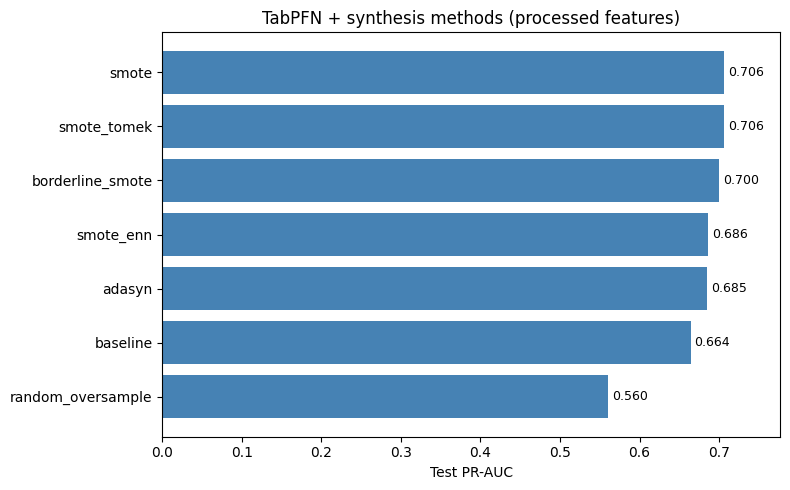

Saved: /kaggle/working/modeling_tabpfn/tabpfn_synthesis_pr_auc.png


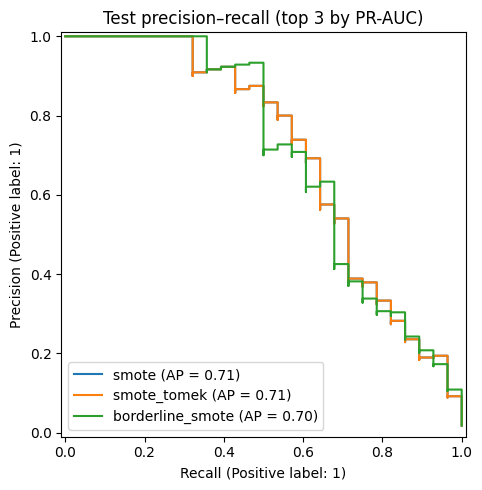

Saved: /kaggle/working/modeling_tabpfn/tabpfn_synthesis_pr_curves.png

Best by test PR-AUC: smote (PR-AUC=0.7060, recall=0.607, precision=0.708)


In [9]:
csv_path = RESULT_DIR / "tabpfn_synthesis_comparison.csv"
comparison.to_csv(csv_path, index=False)
print("Saved:", csv_path)

# PR-AUC bar chart
plot_df = comparison.sort_values("test_pr_auc", ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(plot_df["method"], plot_df["test_pr_auc"], color="steelblue")
ax.set_xlabel("Test PR-AUC")
ax.set_title("TabPFN + synthesis methods (processed features)")
ax.set_xlim(0, max(plot_df["test_pr_auc"].max() * 1.1, 0.1))
for bar, val in zip(bars, plot_df["test_pr_auc"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
bar_path = RESULT_DIR / "tabpfn_synthesis_pr_auc.png"
plt.savefig(bar_path, dpi=150)
plt.show()
print("Saved:", bar_path)

# Overlaid PR curves for top-3 methods by test PR-AUC
top3 = comparison.head(3)["method"].tolist()
fig, ax = plt.subplots(figsize=(7, 5))
for name in top3:
    PrecisionRecallDisplay.from_predictions(
        y_test, probas[name], ax=ax, name=name,
    )
ax.set_title("Test precision–recall (top 3 by PR-AUC)")
plt.tight_layout()
pr_path = RESULT_DIR / "tabpfn_synthesis_pr_curves.png"
plt.savefig(pr_path, dpi=150)
plt.show()
print("Saved:", pr_path)

best = comparison.iloc[0]
print(
    f"\nBest by test PR-AUC: {best['method']} "
    f"(PR-AUC={best['test_pr_auc']:.4f}, recall={best['test_recall']:.3f}, "
    f"precision={best['test_precision']:.3f})"
)

## Notes

- **Random oversampling:** duplicates real minority rows (no interpolation); useful baseline vs SMOTE-style synthesis.
- **Synthetic context rows:** TabPFN stores oversampled training data as in-context examples; this tests whether denser minority regions help ICL under imbalance.
- **Hybrid cleaners** (SMOTE+Tomek / SMOTE+ENN) may leave `train_rows` below full balance — see the `train_rows` column.
- **Kaggle:** enable GPU T4 and set env var `tabpfn_token_h` or add a Kaggle secret with that exact name (also accepts `TABPFN_TOKEN` / `TABPFN_TOKEN_H`).